In [1]:
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.processor import Runner, FuturesExecutor, IterativeExecutor

import vbfprocessor
import awkward as ak
import uproot

import os
import time

import coffea
print(coffea.__version__)
import matplotlib.pyplot as plt
import numpy as np
import hist

2025.10.2


In [2]:
start0 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root"
start1 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"

all_filesets = {"start0": [start0],
          "start1": [start1]}


# all_filesets = {
#     "VBF_SMEFTsim_topU3l_NP1": [
#         "root://cmseos.fnal.gov//store/user/jdickins/vbf-eft/VBF_SMEFTsim_topU3l_NP1/VBF_SMEFTsim_topU3l_NP1_STXS/240425_163141/0000//VBFH_SMEFTsim_"+str(i)+".root" for i in range(1,201)
#     ],
#     "VBF_SMEFTsim_topU3l_Direct_cHbox": [
#          "root://cmseos.fnal.gov//store/user/jennetd/vbf-eft/VBF_SMEFTsim_topU3l_Direct_cHbox/VBF_SMEFTsim_topU3l_Direct_cHbox/230919_233803/0000/VBFH_SMEFTsim_"+str(i)+".root" for i in range(1,201)
#     ]} # deleted most of the files

def run_samp(sample):

    fileset = {}
    fileset[sample] = all_filesets[sample]
    outfile = "coffea/"+sample+".coffea"
    
    p = vbfprocessor.VBFProcessor(isMC=True)
    args = {'savemetrics':True, 'schema':NanoAODSchema}

    output = processor.run_uproot_job(
        fileset,
        treename="Events",
        processor_instance=p,
        executor=processor.iterative_executor,#executor=processor.dask_executor,
        executor_args={'schema': NanoAODSchema,'workers': 4},
        chunksize=50000,
        )

    util.save(output, outfile)
    print("saved " + outfile)

In [3]:
def run_samp(sample):

    fileset = {}
    fileset[sample] = all_filesets[sample]
    outfile = "coffea/"+sample+".coffea"

    #processor that computes stuff like higgs, pt, histograms, etc
    p = vbfprocessor.VBFProcessor(isMC=True)

    #sets how coffea processes events
    executor = FuturesExecutor(workers=4, status=True)

    #create runner instance - this loops over files in fileset and feeds events into processor
    runner = Runner(
        executor=executor,
        savemetrics=True,
        schema=NanoAODSchema,
        chunksize=50000,
    )

    #run job
    output, metrics = runner(
        fileset=fileset,
        processor_instance=p,
        treename="Events",
    )

    util.save(output, outfile)
    print("saved " + outfile)


In [12]:
start0 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root"
start1 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"

cHW_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHW_HT2/VBFH_SMEFTsim_100.root"
cHWtil_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2/VBFH_SMEFTsim_101.root"

all_filesets = {"start0": [start0],
          "start1": [start1],
               "cHW_sample": [cHW_sample],
               "cHWtil_sample": [cHWtil_sample]}

#sample = "VBF_SMEFTsim_topU3l_Direct_cHW_HT2"

sample = "cHW_sample"
fileset = {sample: all_filesets[sample]}

run_samp("cHWtil_sample")

# p = vbfprocessor.VBFProcessor(isMC=True)

# output, metrics = runner(
#     fileset=fileset,
#     processor_instance=p,
#     treename="Events",
# )

# util.save(output, f"coffea/{sample}.coffea")

try1
/uscms_data/d3/azhou/smeft/analysis
names length: 275
first few names: ['cHbox=0.005', 'cHbox=0.01', 'cHDD=0.005', 'cHDD=0.01', 'cHW=0.005']
except


saved coffea/cHWtil_sample.coffea


In [8]:
start0_coffea = util.load("coffea/start0.coffea")
print(start0_coffea.keys())
start0_hpt = start0_coffea["hpt"]
print(start0_hpt)

# for ax in start0_hpt.axes:
#     print(ax.name, ax)

dict_keys(['q1pt', 'q2pt', 'hpt', 'detaqq', 'dphiqq', 'mqq', 'EventCount'])
Hist(
  Regular(200, 0, 1000, name='hpt', label='Higgs $p_{T}$ [GeV]'),
  StrCategory(['cHbox=0.005', 'cHbox=0.01', 'cHDD=0.005', 'cHDD=0.01', 'cHW=0.005', 'cHW=0.01', 'cHB=0.005', 'cHB=0.01', 'cHWB=0.005', 'cHWB=0.01', 'cuWRe=0.005', 'cuWRe=0.01', 'cuBRe=0.005', 'cuBRe=0.01', 'cdWRe=0.005', 'cdWRe=0.01', 'cdBRe=0.005', 'cdBRe=0.01', 'cHj1=0.005', 'cHj1=0.01', 'cHj3=0.005', 'cHj3=0.01', 'cHu=0.005', 'cHu=0.01', 'cHd=0.005', 'cHd=0.01', 'cHudRe=0.005', 'cHudRe=0.01', 'cHWtil=0.005', 'cHWtil=0.01', 'cHBtil=0.005', 'cHBtil=0.01', 'cHWBtil=0.005', 'cHWBtil=0.01', 'cuWIm=0.005', 'cuWIm=0.01', 'ctBIm=0.005', 'ctBIm=0.01', 'cdWIm=0.005', 'cdWIm=0.01', 'cdBIm=0.005', 'cdBIm=0.01', 'cHudIm=0.005', 'cHudIm=0.01', 'cHbox=0.01,cHDD=0.01', 'cHbox=0.01,cHW=0.01', 'cHbox=0.01,cHB=0.01', 'cHbox=0.01,cHWB=0.01', 'cHbox=0.01,cuWRe=0.01', 'cHbox=0.01,cuBRe=0.01', 'cHbox=0.01,cdWRe=0.01', 'cHbox=0.01,cdBRe=0.01', 'cHbox=0.01,cHj1=

Hist(
  Regular(200, 0, 1000, name='hpt', label='Higgs $p_{T}$ [GeV]'),
  StrCategory(['SM'], growth=True, name='wc', label='WC point'),
  storage=Weight()) # Sum: WeightedSum(value=3.55766e+06, variance=1.27404e+07) (WeightedSum(value=3.55909e+06, variance=1.27457e+07) with flow)
Hist(
  Regular(200, 0, 1000, name='hpt', label='Higgs $p_{T}$ [GeV]'),
  StrCategory(['SM'], growth=True, name='wc', label='WC point'),
  storage=Weight()) # Sum: WeightedSum(value=3.76478e+06, variance=1.42622e+07) (WeightedSum(value=3.7658e+06, variance=1.42662e+07) with flow)


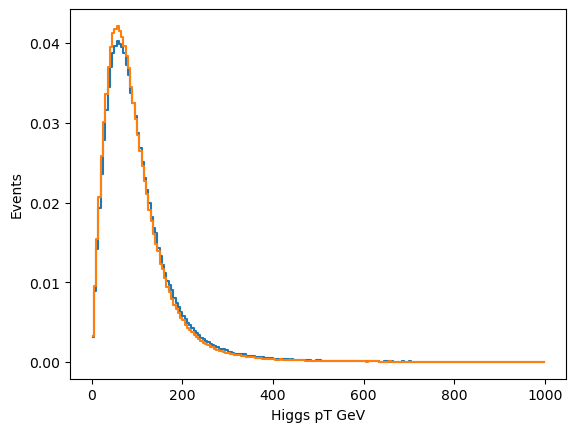

In [63]:
import hist

cHW_coffea_file = util.load("coffea/VBF_SMEFTsim_topU3l_Direct_cHW_HT2.coffea")
cHW_hpt = cHW_coffea_file["hpt"]
print(cHW_hpt)

cHW_hpt_sm = cHW_hpt[{"wc": "SM"}]

cHW_values, cHW_edges = cHW_hpt_sm.to_numpy()
cHW_centers = 0.5 * (cHW_edges[1:] + cHW_edges[:-1])

cHWtil_coffea_file = util.load("coffea/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2.coffea")
cHWtil_hpt = cHWtil_coffea_file["hpt"]
print(cHWtil_hpt)

cHWtil_hpt_sm = cHWtil_hpt[{"wc": "SM"}]

cHWtil_values, cHWtil_edges = cHWtil_hpt_sm.to_numpy()
cHWtil_centers = 0.5 * (cHWtil_edges[1:] + cHWtil_edges[:-1])

cHW_norm = cHW_values / np.sum(cHW_values)
cHWtil_norm = cHWtil_values / np.sum(cHWtil_values)

plt.step(cHW_centers, cHW_norm, where="mid", label="cHW direct SM norm", color='tab:blue')
plt.step(cHWtil_centers, cHWtil_norm, where="mid", label="cHWtil direct SM norm", color='tab:orange')

# hpt_sm_rebinned = hpt_sm[::hist.rebin(5)]
# rebinned_values, rebinned_edges = hpt_sm_rebinned.to_numpy()
# rebinned_centers = 0.5 * (edges_rb[1:] + edges_rb[:-1])
#plt.step(cHW_centers, cHW_values, where="mid")
plt.xlabel("Higgs pT GeV")
plt.ylabel("Events")
#plt.yscale('log')
plt.show()
